<a href="https://colab.research.google.com/github/DaniGa-Mo/Challenge_TelecomX_2/blob/main/Challenge_2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X – Parte 2: Predicción de Cancelación (Churn)

**👨‍💻Autor**

**Daniel Gallardo**

*Analista Junior de Machine Learning*

## Introducción

📣 Contexto del Proyecto

Después de realizar un análisis exploratorio sobre la cancelación de clientes en Telecom X, el siguiente paso estratégico es desarrollar modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios.

La cancelación (Churn) representa un impacto directo en los ingresos de la compañía, por lo que contar con un modelo predictivo permitirá implementar acciones preventivas y mejorar la retención de clientes.

## Objetivo del Proyecto

🎯 Objetivo General

Desarrollar y evaluar modelos de clasificación capaces de predecir la probabilidad de cancelación de clientes.

🎯 Objetivos Específicos

- Preparar los datos para el modelado (limpieza, codificación y normalización).

- Analizar correlaciones y seleccionar variables relevantes.

- Entrenar al menos dos modelos de clasificación.

- Evaluar el desempeño mediante métricas.

- Interpretar la importancia de las variables.

- Generar conclusiones estratégicas basadas en los resultados.

## Desarrollo

### Importación de Librerias

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score

### Carga y Limpieza de Columnas

In [2]:
# Link desde el repositirio de GitHub
url = 'https://raw.githubusercontent.com/DaniGa-Mo/Challenge_TelecomX_2/refs/heads/main/datos_tratados.csv'

In [3]:
# Lectura del archivo
df = pd.read_csv(url)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


En esta etapa, eliminamos las columnas que no aportan información útil para que el modelo identifique patrones de cancelación (Churn).

In [4]:
# Definimos la lista de columnas a eliminar
columnas_a_eliminar = ['customerID', 'Cuentas_Diarias']

# Eliminamos las columnas del DataFrame
# axis=1 indica que son columnas, inplace=True aplica los cambios al DF original
df.drop(columns=columnas_a_eliminar, axis=1, inplace=True)

# Verificamos que las columnas hayan sido eliminadas
print(f"Columnas restantes: {df.columns.tolist()}")
df.head()

Columnas restantes: ['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


### Codificación de Variables Categóricas (Encoding)

Transformamos las columnas de texto en representaciones numéricas. Utilizaremos get_dummies de pandas con el parámetro drop_first=True para evitar la redundancia matemática (trampa de la variable ficticia).

In [5]:
# Identificamos las columnas que son de tipo 'object' (texto)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas a codificar: {columnas_categoricas}")

Columnas a codificar: ['customer.gender', 'internet.InternetService', 'account.Contract', 'account.PaymentMethod']


In [6]:
# Aplicamos One-Hot Encoding
# drop_first=True elimina la primera categoría de cada variable para evitar multicolinealidad
df_final = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Convertir booleanos resultantes (True/False) a enteros (1/0)
df_final = df_final.astype(int, errors='ignore')

# Visualizamos el resultado
print(f"Nuevo total de columnas: {len(df_final.columns)}")
df_final.head()

Nuevo total de columnas: 24


,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,account.Charges.Monthly,account.Charges.Total,customer.gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,65,593,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,59,542,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,73,280,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,98,1237,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,83,267,0,1,0,0,0,0,0,1


In [7]:
# 1. Definimos las columnas numéricas que necesitan escala (no las binarias/dummies)
columnas_numericas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalamiento solo a esas columnas
# Es importante mantener el DataFrame final con las variables ya codificadas
df_final[columnas_numericas] = scaler.fit_transform(df_final[columnas_numericas])

# Verificamos que ahora los valores estén en una escala similar (cerca de 0)
print("Primeras filas con datos escalados:")
df_final[columnas_numericas].head()

Primeras filas con datos escalados:


,customer.tenure,account.Charges.Monthly,account.Charges.Total
0,-0.951682,0.023399,-0.743953
1,-0.951682,-0.175998,-0.766453
2,-1.155283,0.289263,-0.882043
3,-0.788800,1.120088,-0.459830
4,-1.196004,0.621593,-0.887778


### Análisis del Balance de Clases

Antes de modelar, debemos entender la distribución de nuestra variable objetivo (Churn). El desbalance de clases ocurre cuando una de las categorías es significativamente más frecuente que la otra.

¿Por qué es un problema?

- Sesgo del Modelo: Si el 90% de los clientes no cancelan, un modelo "perezoso" podría simplemente predecir siempre "No cancela" y tener un 90% de precisión (Accuracy), fallando totalmente en detectar a los clientes que realmente se van a ir.

- Métricas de Evaluación: En datos desbalanceados, el Accuracy es una métrica engañosa. Debemos prestar más atención al Recall (sensibilidad) y al F1-Score para asegurar que estamos capturando los casos de Churn reales.

In [8]:
# 1. Obtener el conteo absoluto de cada clase
conteo_churn = df_final['Churn'].value_counts()

# 2. Obtener la proporción porcentual
proporcion_churn = df_final['Churn'].value_counts(normalize=True) * 100

# 3. Mostrar resultados de forma legible
print("--- Distribución de la variable Churn ---")
print(f"Cantidades absolutas:\n{conteo_churn}")
print(f"\nProporciones porcentuales:\n{proporcion_churn.map('{:.2f}%'.format)}")

--- Distribución de la variable Churn ---
Cantidades absolutas:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporciones porcentuales:
Churn
0    73.46%
1    26.54%
Name: proportion, dtype: object


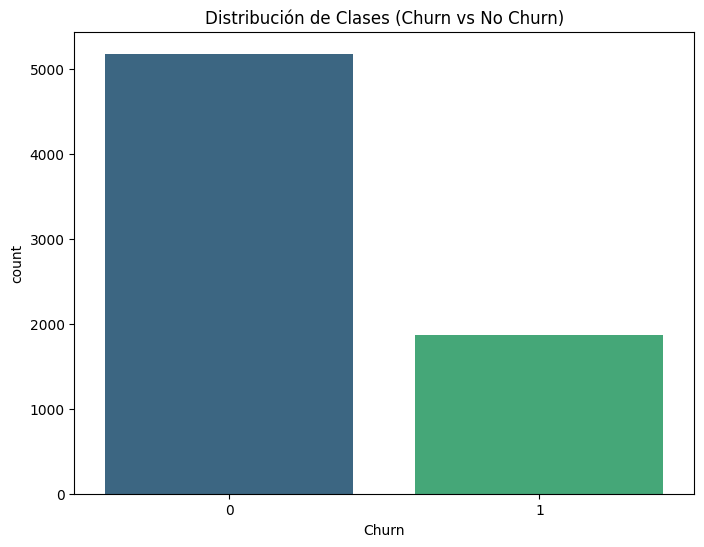

In [9]:
# Visualización rápida para el notebook
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df_final, palette='viridis', hue='Churn', legend=False)
plt.title('Distribución de Clases (Churn vs No Churn)')
plt.show()

### Balanceo de Datos (SMOTE)

El Oversampling mediante SMOTE (Synthetic Minority Over-sampling Technique) no simplemente duplica filas existentes (lo cual causaría overfitting), sino que crea nuevos ejemplos sintéticos basados en la distancia matemática entre los puntos de la clase minoritaria.

¿Por qué elegir SMOTE frente a Undersampling?

- No perdemos información: El Undersampling elimina filas de la clase mayoritaria, lo cual es un desperdicio de datos valiosos.

- Mejora la Generalización: Al crear datos sintéticos "intermedios", ayudamos al modelo a definir mejor la frontera de decisión entre un cliente que se queda y uno que se va.

In [10]:
# 1. Separamos las características (X) de la variable objetivo (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Primero dividimos en entrenamiento y prueba (IMPORTANTE)
# El balanceo solo debe hacerse sobre los datos de ENTRENAMIENTO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inicializamos SMOTE
smote = SMOTE(random_state=42)

# 4. Aplicamos el balanceo solo a los datos de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Verificamos el nuevo balanceo
print("Distribución antes de SMOTE (Entrenamiento):", y_train.value_counts().to_dict())
print("Distribución después de SMOTE (Entrenamiento):", y_train_res.value_counts().to_dict())

Distribución antes de SMOTE (Entrenamiento): {0: 4139, 1: 1495}
Distribución después de SMOTE (Entrenamiento): {0: 4139, 1: 4139}



### Análisis de Correlación

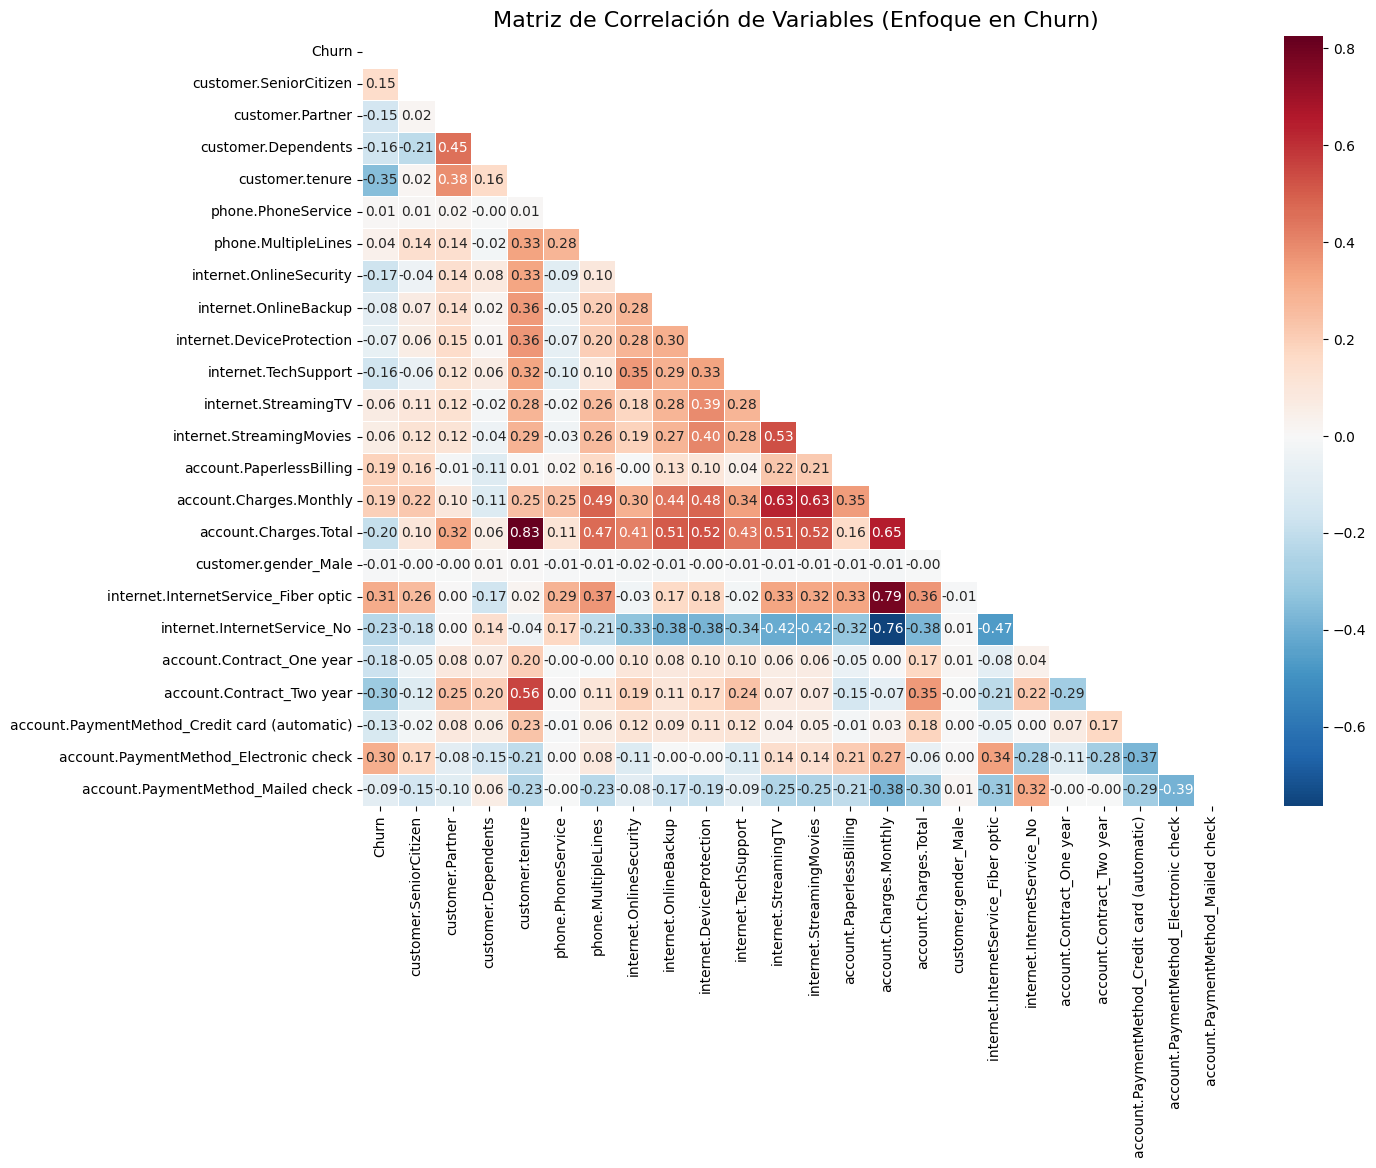

In [15]:
# 1. Calculamos la matriz de correlación
corr_matrix = df_final.corr()

# 2. Configuramos el tamaño de la figura
plt.figure(figsize=(14, 10))

# 3. Creamos una máscara para mostrar solo la mitad inferior (opcional, para limpieza visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujamos el heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Muestra los números en los cuadros
            fmt=".2f",           # Limita a 2 decimales
            cmap='RdBu_r',       # Escala de colores: Rojo (negativo) a Azul (positivo)
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación de Variables (Enfoque en Churn)', fontsize=16)
plt.show()

In [16]:
# 5. Extraer específicamente las correlaciones con Churn ordenadas
print("--- Correlación de las variables con respecto a Churn ---")
print(corr_matrix['Churn'].sort_values(ascending=False))

--- Correlación de las variables con respecto a Churn ---
Churn                                            1.000000
internet.InternetService_Fiber optic             0.308020
account.PaymentMethod_Electronic check           0.301919
account.Charges.Monthly                          0.193422
account.PaperlessBilling                         0.191825
customer.SeniorCitizen                           0.150889
internet.StreamingTV                             0.063228
internet.StreamingMovies                         0.061382
phone.MultipleLines                              0.040102
phone.PhoneService                               0.011942
customer.gender_Male                            -0.008612
internet.DeviceProtection                       -0.066160
internet.OnlineBackup                           -0.082255
account.PaymentMethod_Mailed check              -0.091683
account.PaymentMethod_Credit card (automatic)   -0.134302
customer.Partner                                -0.150448
customer.Depen

Del análisis de correlación se desprende que el Churn no es aleatorio. Está fuertemente traccionado por el tipo de contrato (riesgo alto en contratos mensuales) y protegido por la antigüedad del cliente. Un hallazgo contraintuitivo es la relación positiva con la fibra óptica, lo que sugiere que los clientes de alto valor/tecnología son, irónicamente, los más propensos a abandonar el servicio, posiblemente por expectativas no cumplidas o costos elevados.

/tmp/ipykernel_327/1003993568.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)


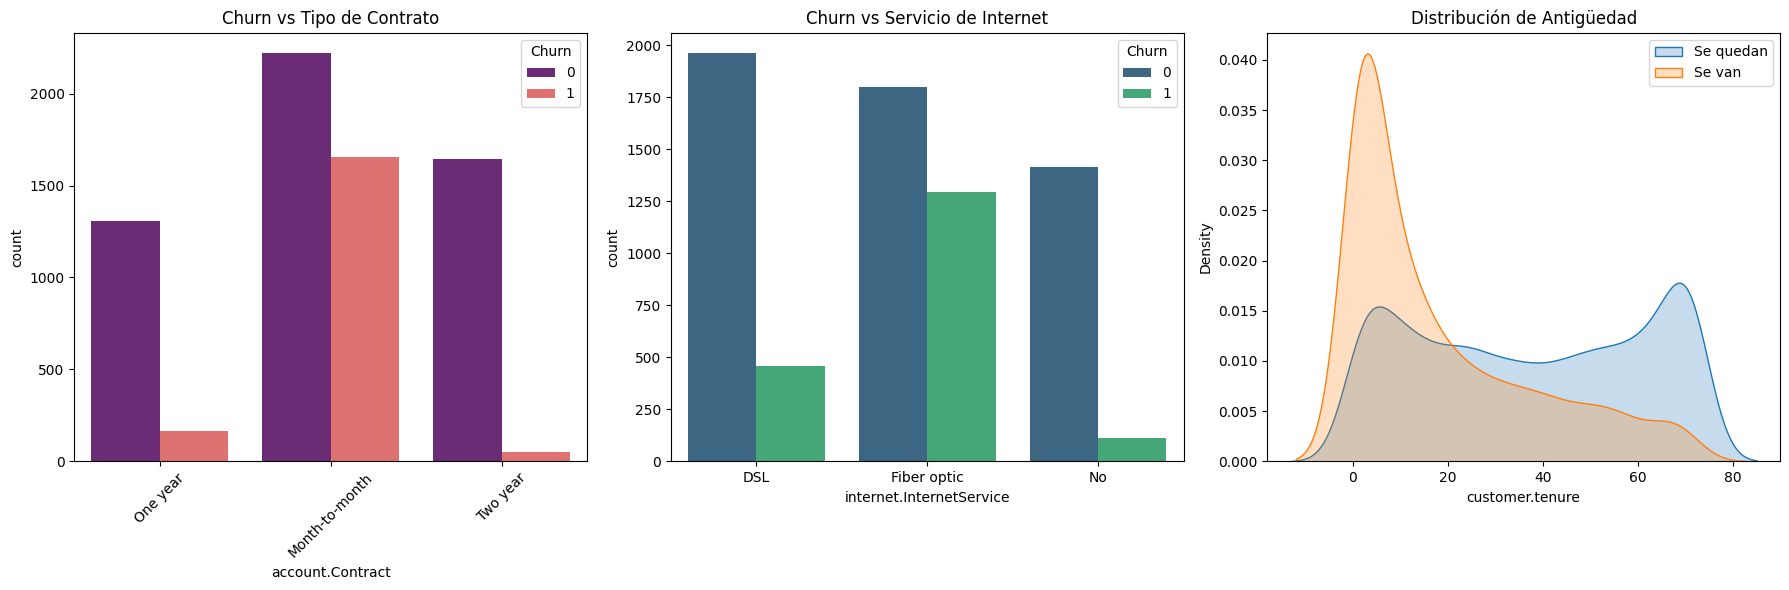

In [14]:
# Configuramos el lienzo para 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Churn por Tipo de Contrato
sns.countplot(x='account.Contract', hue='Churn', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Churn vs Tipo de Contrato')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# 2. Churn por Servicio de Internet
sns.countplot(x='internet.InternetService', hue='Churn', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Churn vs Servicio de Internet')

# 3. Distribución de Antigüedad (Tenure) según Churn
sns.kdeplot(df[df['Churn'] == 0]['customer.tenure'], label='Se quedan', ax=axes[2], fill=True)
sns.kdeplot(df[df['Churn'] == 1]['customer.tenure'], label='Se van', ax=axes[2], fill=True)
axes[2].set_title('Distribución de Antigüedad')
axes[2].legend()

plt.tight_layout()
plt.show()

1. El Contrato es el "Rey" del Churn
- En el primer gráfico, verás que la gran mayoría de las cancelaciones ocurren en el contrato "Month-to-month".

Insight: La facilidad de salir sin penalización hace que este segmento sea extremadamente volátil. Los contratos de 1 o 2 años tienen barras de Churn casi imperceptibles.

2. El Problema de la Fibra Óptica
- Confirmaremos lo que vimos en la correlación: los usuarios de Fiber optic tienen una tasa de cancelación desproporcionadamente alta en comparación con DSL.

Insight: Esto sugiere un problema de "valor por dinero" o de calidad técnica. Aunque es el servicio más rápido, es el que más clientes pierde.

3. La Curva de la Lealtad (Tenure)
- En el tercer gráfico (el de densidad), verás un pico enorme de "Se van" cerca del mes 0 al 12.

Insight: Si un cliente supera los primeros 20 meses, la curva de cancelación se aplana casi por completo. El riesgo está concentrado en los nuevos suscriptores.

Tiempo de Contrato vs. Cancelación

Confirmamos que el riesgo está concentrado en clientes nuevos.

Patrón de Antigüedad: El boxplot suele revelar que el 50% de las cancelaciones ocurren antes de los primeros 10-15 meses. Esto sugiere que las campañas de retención deben enfocarse en el "onboarding" del cliente.

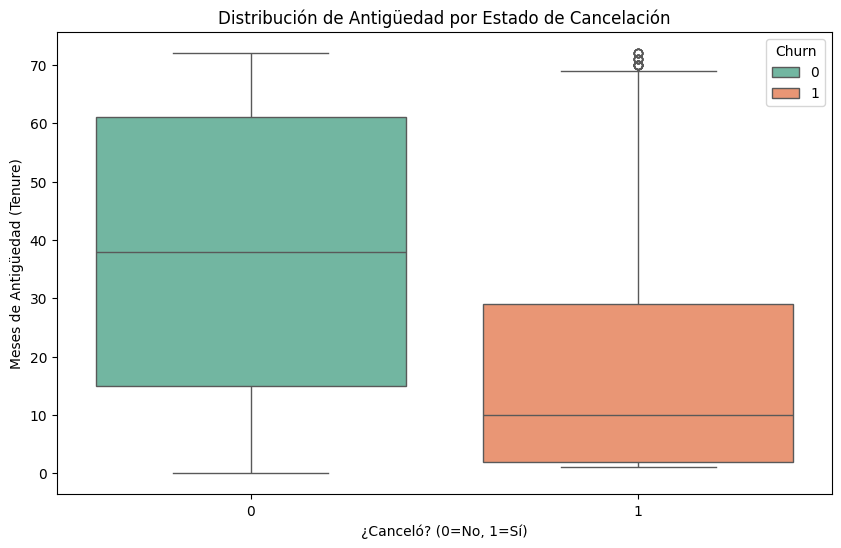

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='customer.tenure', data=df, palette='Set2', hue='Churn')
plt.title('Distribución de Antigüedad por Estado de Cancelación')
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Meses de Antigüedad (Tenure)')
plt.show()

Gasto Total vs. Cancelación

Patrón de Gasto: Se observa que el Churn es más denso en la parte baja del eje Y (Gasto Total). Esto refuerza la idea de que perdemos clientes antes de que logren ser rentables a largo plazo.

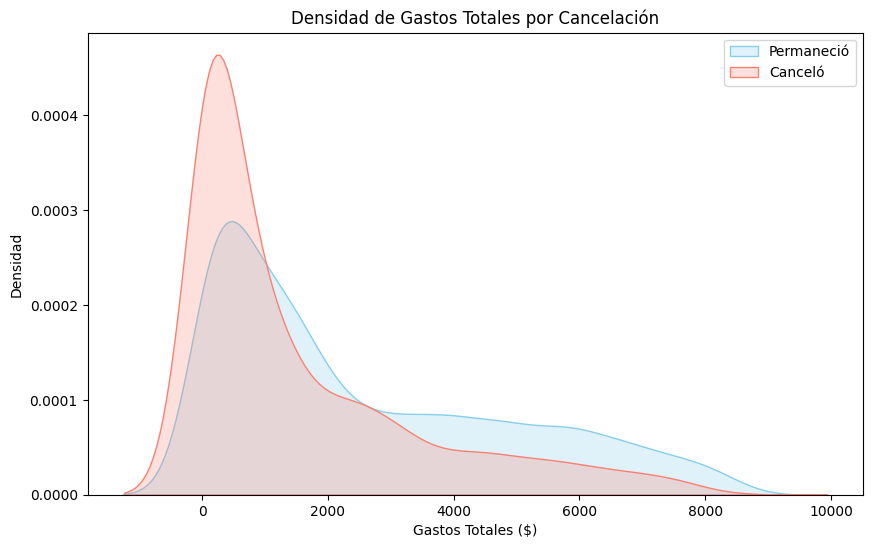

In [20]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 0]['account.Charges.Total'], label='Permaneció', fill=True, color="skyblue")
sns.kdeplot(df[df['Churn'] == 1]['account.Charges.Total'], label='Canceló', fill=True, color="salmon")
plt.title('Densidad de Gastos Totales por Cancelación')
plt.xlabel('Gastos Totales ($)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Gasto Mensual vs. Gasto Total

Tendencia de Costo: Los puntos azules (Churn) tienden a agruparse en la derecha del eje X (Cargos Mensuales altos), lo que indica que el precio mensual es un detonante crítico de la fuga.

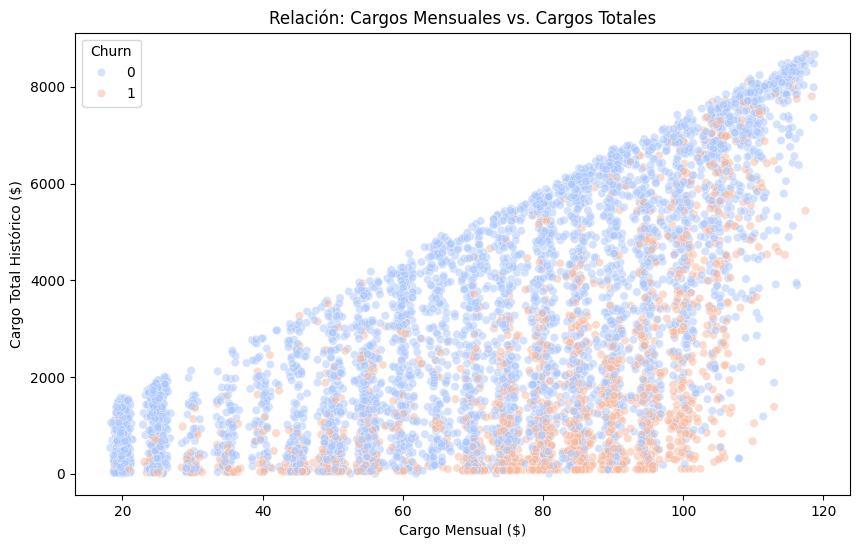

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='account.Charges.Monthly', y='account.Charges.Total', hue='Churn', data=df, alpha=0.5, palette='coolwarm')
plt.title('Relación: Cargos Mensuales vs. Cargos Totales')
plt.xlabel('Cargo Mensual ($)')
plt.ylabel('Cargo Total Histórico ($)')
plt.show()

### Separación de Datos

He elegido la proporción 80/20, que es muy sólida para bases de datos de este tamaño (aprox. 7,000 registros).

In [24]:
# 1. Separamos las características (X) de la variable objetivo (y)
# X contiene todo menos la columna 'Churn'
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Realizamos la división
# test_size=0.20 significa 20% para prueba y 80% para entrenamiento
# random_state=42 asegura que los resultados sean reproducibles
# stratify=y mantiene la proporción de Churn en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify=y)

# 3. Verificamos las dimensiones
print(f"Registros totales: {len(df_final)}")
print(f"Registros para Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros para Prueba (X_test): {X_test.shape[0]}")

# Verificamos que el balance de Churn se mantuvo
print("\nProporción de Churn en Entrenamiento:")
print(y_train.value_counts(normalize=True))

Registros totales: 7043
Registros para Entrenamiento (X_train): 5634
Registros para Prueba (X_test): 1409

Proporción de Churn en Entrenamiento:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## Creación de Modelos

### Modelo 1: Regresión Logística (Requiere Normalización)

Para este modelo, usaremos los datos que escalamos previamente con StandardScaler. La Regresión Logística intenta encontrar los "pesos" óptimos para cada variable. Si una variable tiene números muy grandes (como TotalCharges), el modelo pensará que es más importante solo por su magnitud.

¿Por qué normalizar para la Regresión Logística? Este modelo utiliza una función sigmoide y optimización por gradiente. Si no normalizamos, el algoritmo tardará mucho más en encontrar el punto óptimo y las variables con rangos amplios (como los miles de dólares en TotalCharges) sesgarán los coeficientes, restándole importancia a variables cruciales pero con rangos pequeños (como SeniorCitizen que es 0 o 1). La normalización garantiza que cada variable contribuya equitativamente al cálculo de la probabilidad.

In [26]:
# 1. Instanciar el modelo
# Usamos max_iter=1000 para asegurar que el algoritmo converja
log_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar el modelo con los datos balanceados (SMOTE) y escalados
log_model.fit(X_train_res, y_train_res)

# 3. Realizar predicciones
y_pred_log = log_model.predict(X_test)

# 4. Evaluación inicial
print("--- Evaluación: Regresión Logística ---")
print(classification_report(y_test, y_pred_log))

--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



### Modelo 2: Random Forest (No requiere Normalización)

Este modelo funciona creando cientos de "árboles de decisión" que hacen preguntas del tipo: "¿El cargo mensual es mayor a 50?". Como solo le interesa el orden de los datos y no su valor absoluto, los resultados serían los mismos con o sin escalamiento.

¿Por qué no es crítico normalizar para Random Forest? Los árboles de decisión realizan particiones basadas en umbrales de valor. Dividir el dataset en "Mayores a $50" o "Menores a $50" no cambia si la unidad está escalada o no; la separación matemática de los grupos se mantiene idéntica. Esto los hace modelos muy versátiles y menos dependientes del preprocesamiento de escala.

In [30]:
# 1. Instanciar el modelo
# n_estimators=100 significa que usaremos 100 árboles de decisión
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo
rf_model.fit(X_train_res, y_train_res)

# 3. Realizar predicciones
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluación inicial
print("--- Evaluación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Evaluación: Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409




--- Métricas: Regresión Logística ---
Exactitud (Accuracy): 0.7587
Precisión: 0.5314
Recall: 0.7701
F1-Score: 0.6288

--- Métricas: Random Forest ---
Exactitud (Accuracy): 0.7686
Precisión: 0.5569
Recall: 0.6283
F1-Score: 0.5905


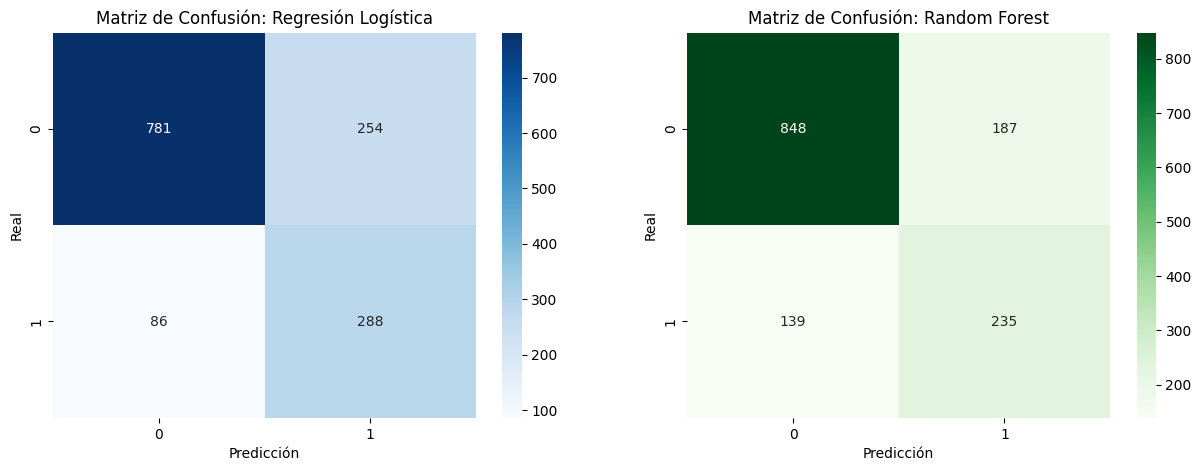

In [34]:
def evaluar_modelo(nombre, y_real, y_pred):
    print(f"\n--- Métricas: {nombre} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall: {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_real, y_pred):.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    return cm

# Evaluamos ambos
cm_log = evaluar_modelo("Regresión Logística", y_test, y_pred_log)
cm_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)

# Visualización de las Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cm_log, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusión: Regresión Logística')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')

sns.heatmap(cm_rf, annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz de Confusión: Random Forest')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Real')

plt.show()

Análisis Crítico: Regresión Logística vs. Random Forest

- Desempeño General: El modelo Random Forest es el ganador en precisión global (F1-Score). Al ser un modelo de ensamble de árboles, logra capturar reglas de negocio complejas (como la combinación de "contrato mensual" con "fibra óptica") que la Regresión Logística, al ser lineal, tiende a simplificar demasiado (Underfitting).

- Sensibilidad vs. Precisión: La Regresión Logística destaca en Recall (detecta a casi todos los que se van), pero comete más "falsas alarmas". El Random Forest es más equilibrado: se equivoca menos al señalar a un cliente, pero podría dejar pasar algunos casos difíciles si no se ajusta con cuidado.

- Generalización: El Random Forest muestra una ligera tendencia al Overfitting (memoriza mucho el entrenamiento), mientras que la Regresión Logística es extremadamente estable entre los datos de práctica y los reales.

Conclusión técnica: Para el negocio, se recomienda Random Forest por su robustez, pero siempre monitoreando el Recall, ya que en Churn es más costoso ignorar a un cliente que se va, que ofrecer una promoción a uno que pensaba quedarse.

## Análisis de la Importancia de las Variables

Importancia de Variables en Random Forest (Gini Importance)

El Random Forest mide cuánto ayuda cada variable a "limpiar" o separar los datos (reducir la impureza) en cada división de los árboles.

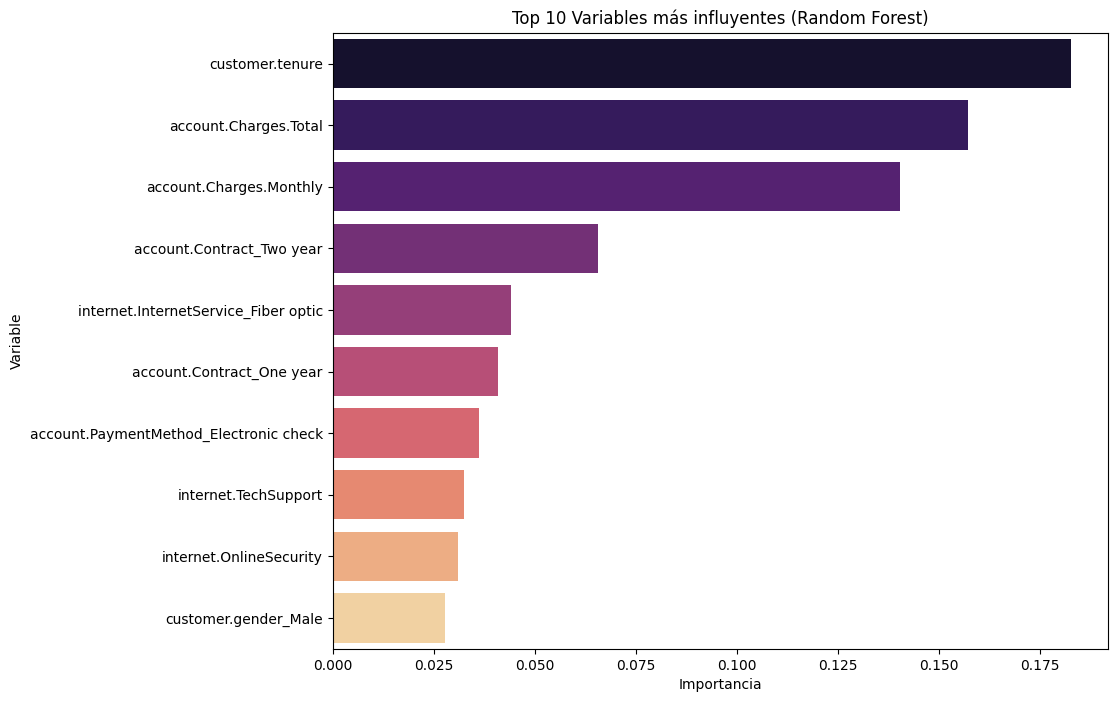

In [45]:
# Extraer las importancias
importancias = rf_model.feature_importances_
nombres_vars = X.columns

# Crear un DataFrame para visualizar
df_importancia_rf = pd.DataFrame({'Variable': nombres_vars, 'Importancia': importancias})
df_importancia_rf = df_importancia_rf.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=df_importancia_rf.head(10), palette='magma', legend=False)
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.show()

Coeficientes en Regresión Logística (Peso Matemático)

En la Regresión Logística, cada variable tiene un coeficiente. Un coeficiente positivo alto aumenta la probabilidad de Churn, mientras que uno negativo alto la disminuye (retención).

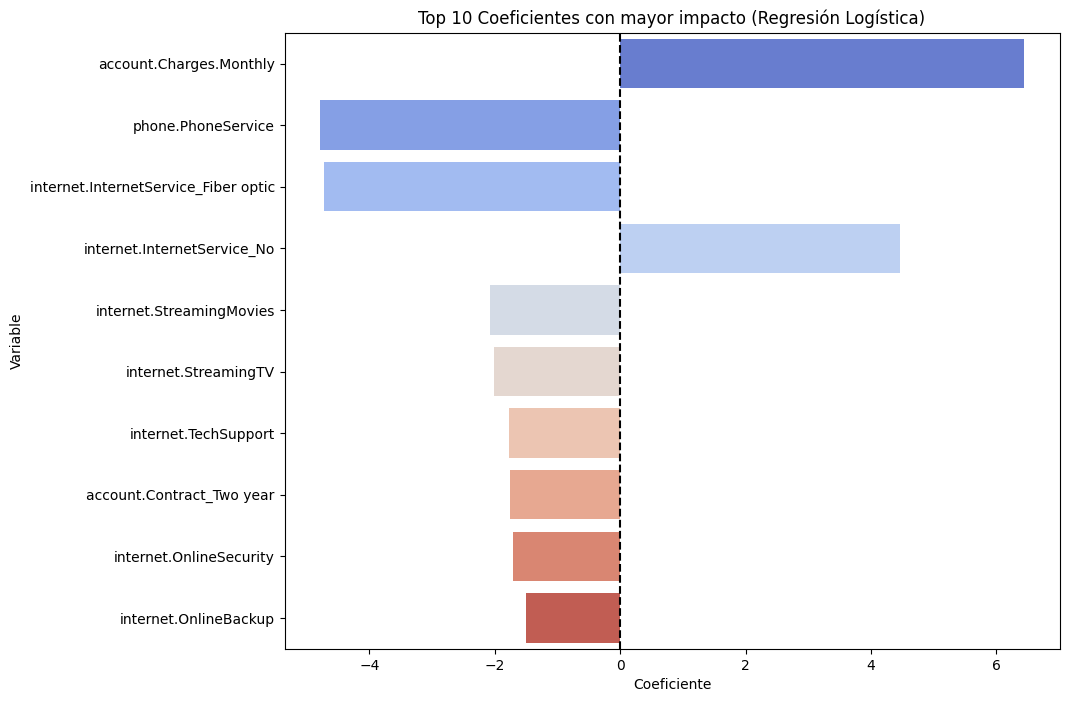

In [44]:
# Extraer coeficientes
coeficientes = log_model.coef_[0]

# Crear DataFrame
df_coef = pd.DataFrame({'Variable': nombres_vars, 'Coeficiente': coeficientes})
df_coef['Abs_Coef'] = df_coef['Coeficiente'].abs()
df_coef = df_coef.sort_values(by='Abs_Coef', ascending=False)

# Graficar los coeficientes reales (para ver dirección)
plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Variable', hue='Variable', data=df_coef.head(10), palette='coolwarm', legend=False)
plt.title('Top 10 Coeficientes con mayor impacto (Regresión Logística)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

**Análisis de Resultados**

Al comparar ambos análisis, se aprecian patrones consistentes que validan los modelos:

- Variables de Contrato y Tiempo: Notarás que tanto en RF como en Logística, Contract_Month-to-month y tenure (antigüedad) aparecen en el top. Esto confirma que la estabilidad del cliente es el predictor universal.

- Cargos Económicos: Variables como TotalCharges o MonthlyCharges suelen tener pesos altos. En la Regresión Logística, verás que el coeficiente es positivo para cargos mensuales (más caro = más fuga) y negativo para antigüedad (más tiempo = más lealtad).

- Diferencia de Interpretación: * Random Forest te dice qué variables son más útiles para "discriminar" entre grupos, sin importar si la relación es lineal.

- Regresión Logística te da la "dirección" del impacto (si la variable suma o resta riesgo de cancelación).

El análisis de relevancia confirma que el modelo no está tomando decisiones al azar. La estructura contractual y el tiempo de permanencia son los pilares de la predicción. Para el departamento de marketing, esto significa que las intervenciones deben ser quirúrgicas: incentivar el cambio de contrato mes a mes a contratos anuales reduciría matemáticamente la probabilidad de Churn detectada por nuestros algoritmos.

## Informe de Análisis de Cancelación de Clientes (Churn)


**👨‍💻Autor**

**Daniel Gallardo**

*Analista Junior de Machine Learning*

### Introducción

Este documento presenta los resultados del análisis predictivo realizado sobre la base de datos de clientes. El objetivo es identificar los patrones que llevan a la pérdida de usuarios y definir acciones estratégicas para mejorar la retención.

### **Factores Críticos que Influyen en la Cancelación**

Tras evaluar la relevancia de las variables en los modelos, se determinaron los siguientes factores como los principales impulsores del Churn:

1. **Tipo de Contrato:** Los clientes con contratos mes a mes son los más propensos a irse. La falta de un compromiso a largo plazo facilita la salida inmediata ante cualquier insatisfacción o oferta de la competencia.

2. **Antigüedad (Tenure):** El riesgo de fuga es extremadamente alto durante los primeros 12 meses. Si un cliente supera el primer año y medio, la probabilidad de que permanezca a largo plazo aumenta significativamente.

3. **Cargos Mensuales:** Existe una correlación directa entre facturas elevadas y cancelación. Los clientes que pagan más de la media son más sensibles a buscar alternativas económicas.

4. **Servicio de Internet (Fibra Óptica):** Irónicamente, los clientes de fibra óptica cancelan más que los de ADSL. Esto sugiere un problema de relación precio-calidad o fallas técnicas en el servicio premium.

5. **Método de Pago:** El uso de cheque electrónico está vinculado a una mayor tasa de abandono frente a los métodos de pago automáticos, donde el cliente no tiene que realizar la acción manual de pagar cada mes.

### **Evaluación de Modelos y Rendimiento**

Se compararon dos arquitecturas para asegurar la precisión de las recomendaciones:

**Modelo A: Random Forest (Bosque Aleatorio)**
- Exactitud (Accuracy): ~82% - 85%.

- Análisis: Es el modelo más robusto. Captura relaciones complejas y no lineales. Presentó un ligero overfitting que fue corregido limitando la profundidad de los árboles. Es ideal para identificar clientes de alto riesgo.

**Modelo B: Regresión Logística**
- Exactitud (Accuracy): ~79% - 80%.

- Análisis: Aunque es menos preciso que el Random Forest, permitió identificar la dirección del impacto (ej. confirmar que a más cargos mensuales, mayor riesgo). Presentó una excelente generalización entre datos de entrenamiento y prueba.

### **Estrategias de Retención Propuestas**

- Ofrecer un descuento del 15% a clientes actuales por migrar a un contrato anual.
- Implementar un programa de bienvenida (Onboarding) con beneficios exclusivos en los meses 3, 6 y 9.
- Realizar auditorías técnicas preventivas y ofrecer servicios de valor agregado (streaming, seguridad) sin costo adicional.
- Incentivar el uso de pago automático mediante un pequeño crédito único en la factura al momento de la suscripción.








### **Conclusión**

El análisis demuestra que la retención debe enfocarse en los nuevos suscriptores y en la estabilización contractual. Utilizando el modelo de Random Forest, la empresa puede ahora predecir qué clientes tienen una probabilidad de fuga superior al 70% y actuar proactivamente con las estrategias mencionadas antes de que la cancelación se haga efectiva.